In [1]:
import os, sys
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import mne

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
try:
    import pyriemann
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "pyriemann"], check=True)
    import pyriemann

from pyriemann.estimation import Covariances
from pyriemann.classification import FgMDM


In [2]:
# ============================================================
# SETTINGS
# ============================================================

DATA_DIR = r"E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set"

SUBJECTS = ["P1", "P2", "P3"]
STAGES   = ["pre", "post"]

CH_NAMES = [
    "FC3", "FCz", "FC4",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "Pz"
]

EVENT_ID = {"left_hand": 1, "right_hand": 2}

TMIN     = 2.0
TMAX     = 8.0
BASELINE = (2.0, 2.5)

FILTER_BANKS = [
    (8,  12),
    (12, 16),
    (16, 20),
    (20, 24),
    (24, 30),
]

N_SPLITS     = 5
RANDOM_STATE = 42


In [3]:
# ============================================================
# DATA LOADING
# ============================================================

def load_mat_file(filepath, scale_to_volts=True):
    mat  = sio.loadmat(filepath)
    fs   = int(mat["fs"].squeeze())
    y    = mat["y"]
    trig = mat["trig"].squeeze()
    if scale_to_volts:
        y = y * 1e-6
    return y, trig, fs


def extract_events_from_trigger(trig):
    trig   = trig.flatten()
    onsets = np.where(np.diff((trig != 0).astype(int)) == 1)[0] + 1
    codes  = np.where(trig[onsets] == 1, 1, 2)
    return np.column_stack([onsets, np.zeros(len(onsets), dtype=int), codes])


def make_raw(filepath):
    y, trig, fs = load_mat_file(filepath)
    info = mne.create_info(ch_names=CH_NAMES, sfreq=fs, ch_types=["eeg"]*len(CH_NAMES))
    mne.channels.make_standard_montage("standard_1020")
    info.set_montage(mne.channels.make_standard_montage("standard_1020"), on_missing="ignore")
    raw = mne.io.RawArray(y.T, info, verbose=False)
    raw.set_eeg_reference("average", projection=False, verbose=False)
    return raw, extract_events_from_trigger(trig), fs


def make_epochs_for_band(filepath, l_freq, h_freq):
    raw, events, fs = make_raw(filepath)
    raw_filt = raw.copy().filter(l_freq=l_freq, h_freq=h_freq,
                                  fir_design="firwin", verbose=False)
    epochs = mne.Epochs(raw_filt, events, event_id=EVENT_ID,
                        tmin=TMIN, tmax=TMAX, baseline=BASELINE,
                        preload=True, picks="eeg", verbose=False)
    return epochs, epochs.get_data(), epochs.events[:, 2], fs


def make_filterbank_epochs(filepath):
    X_bands, y_ref, epochs_ref, fs_ref = [], None, None, None
    for l_freq, h_freq in FILTER_BANKS:
        epochs, X, y, fs = make_epochs_for_band(filepath, l_freq, h_freq)
        X_bands.append(X)
        if y_ref is None:
            y_ref, epochs_ref, fs_ref = y, epochs, fs
        else:
            assert np.array_equal(y_ref, y), "Label mismatch across filter banks"
    return epochs_ref, np.stack(X_bands, axis=1), y_ref, fs_ref


In [4]:
# ============================================================
# FILTER-BANK TRANSFORMERS
# ============================================================

class FilterBankZScore(BaseEstimator, TransformerMixin):
    """Z-score each band independently (trials x bands x channels x samples)."""
    def fit(self, X, y=None):
        self.mean_ = X.mean(axis=(0, 3), keepdims=True)
        self.std_  = X.std(axis=(0, 3),  keepdims=True)
        self.std_[self.std_ == 0] = 1.0
        return self
    def transform(self, X):
        return (X - self.mean_) / self.std_


class FilterBankCovariances(BaseEstimator, TransformerMixin):
    """Per-band SPD covariance -> block-diagonal matrix (bands*ch x bands*ch)."""
    def __init__(self, estimator="lwf"):
        self.estimator = estimator
    def fit(self, X, y=None):
        self.covs_ = []
        for b in range(X.shape[1]):
            c = Covariances(estimator=self.estimator)
            c.fit(X[:, b, :, :])
            self.covs_.append(c)
        return self
    def transform(self, X):
        n, nb, nc = X.shape[0], X.shape[1], X.shape[2]
        C = np.zeros((n, nb*nc, nb*nc))
        for b, cov in enumerate(self.covs_):
            Cb = cov.transform(X[:, b, :, :])
            s, e = b*nc, (b+1)*nc
            C[:, s:e, s:e] = Cb
        return C


In [5]:
# ============================================================
# FB-FgMDM PIPELINE
# ============================================================

def build_fb_fgmdm_pipeline():
    return Pipeline([
        ("zscore", FilterBankZScore()),
        ("fb_cov", FilterBankCovariances(estimator="lwf")),
        ("fgmdm",  FgMDM(metric="riemann")),
    ])


In [6]:
# ============================================================
# VISUALIZATION (broad-band 8-30 Hz preview)
# ============================================================

def plot_some_eeg_trials(epochs, y, subject, stage, n_trials=3):
    data, times = epochs.get_data(), epochs.times
    print(f"\nEpoch data shape: {data.shape}")
    for idx in range(min(n_trials, len(data))):
        label = "left_hand" if y[idx]==1 else "right_hand"
        plt.figure(figsize=(14, 8))
        offset = 0
        for ch in range(data.shape[1]):
            sig = data[idx, ch, :] * 1e6
            plt.plot(times, sig + offset, linewidth=0.8)
            offset += np.nanmax(np.abs(sig)) * 2.2 + 1e-6
        plt.title(f"EEG | {subject} {stage} | Trial {idx} | {label}")
        plt.xlabel("Time (s)"); plt.ylabel("Channels (offset)")
        plt.grid(alpha=0.3); plt.show()


def compute_channel_intensity(epochs):
    return np.mean(epochs.get_data() ** 2, axis=(0, 2))


def plot_electrode_intensity_bar(epochs, subject, stage):
    iv = compute_channel_intensity(epochs) * 1e12
    plt.figure(figsize=(12, 5))
    plt.bar(epochs.ch_names, iv)
    plt.xticks(rotation=45); plt.ylabel("Mean Power (uV^2)")
    plt.title(f"Electrode Intensities | {subject} {stage}")
    plt.grid(axis="y", alpha=0.3)
    for i, v in enumerate(iv):
        plt.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
    plt.show()


def plot_scalp_intensity(epochs, subject, stage):
    iv = compute_channel_intensity(epochs) * 1e12
    fig, ax = plt.subplots(figsize=(6, 5))
    im, _ = mne.viz.plot_topomap(iv, epochs.info, axes=ax,
                                  show=False, contours=6,
                                  names=epochs.ch_names, sensors=True)
    ax.set_title(f"Scalp Intensity | {subject} {stage}")
    plt.colorbar(im, ax=ax, label="Mean Power (uV^2)"); plt.show()


def visualize_one_dataset(subject="P1", stage="pre"):
    fp = os.path.join(DATA_DIR, f"{subject}_{stage}_training.mat")
    epochs, X, y, fs = make_epochs_for_band(fp, 8, 30)
    print("="*70); print(f"VISUALIZATION | {subject} {stage}"); print("="*70)
    print(f"fs={fs} Hz  shape={X.shape}  labels={dict(zip(*np.unique(y, return_counts=True)))}")
    plot_some_eeg_trials(epochs, y, subject, stage, n_trials=3)
    plot_electrode_intensity_bar(epochs, subject, stage)
    plot_scalp_intensity(epochs, subject, stage)


VISUALIZATION | P1 pre
fs=256 Hz  shape=(80, 16, 1537)  labels={np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Epoch data shape: (80, 16, 1537)


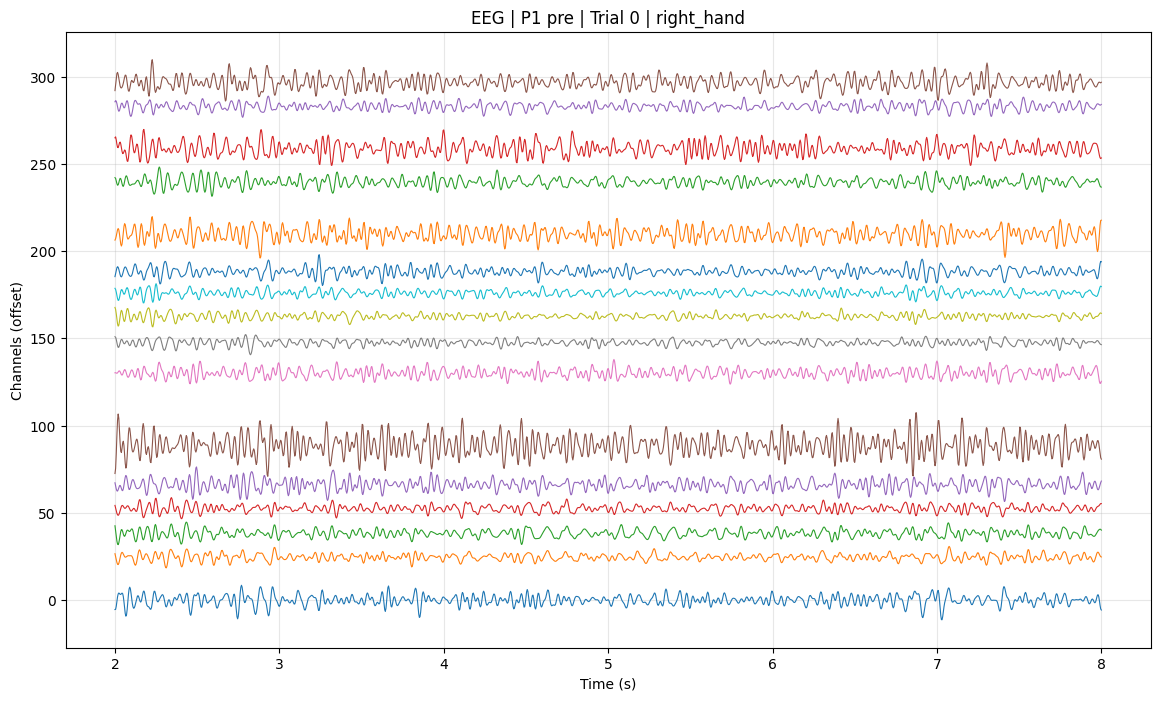

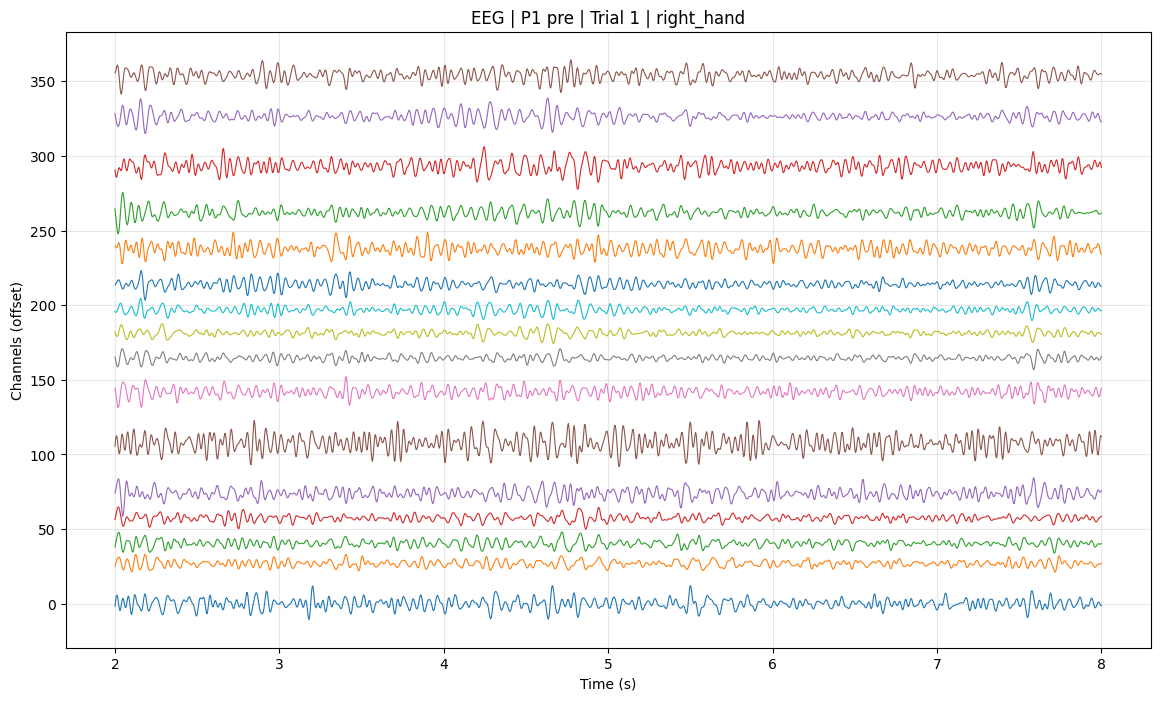

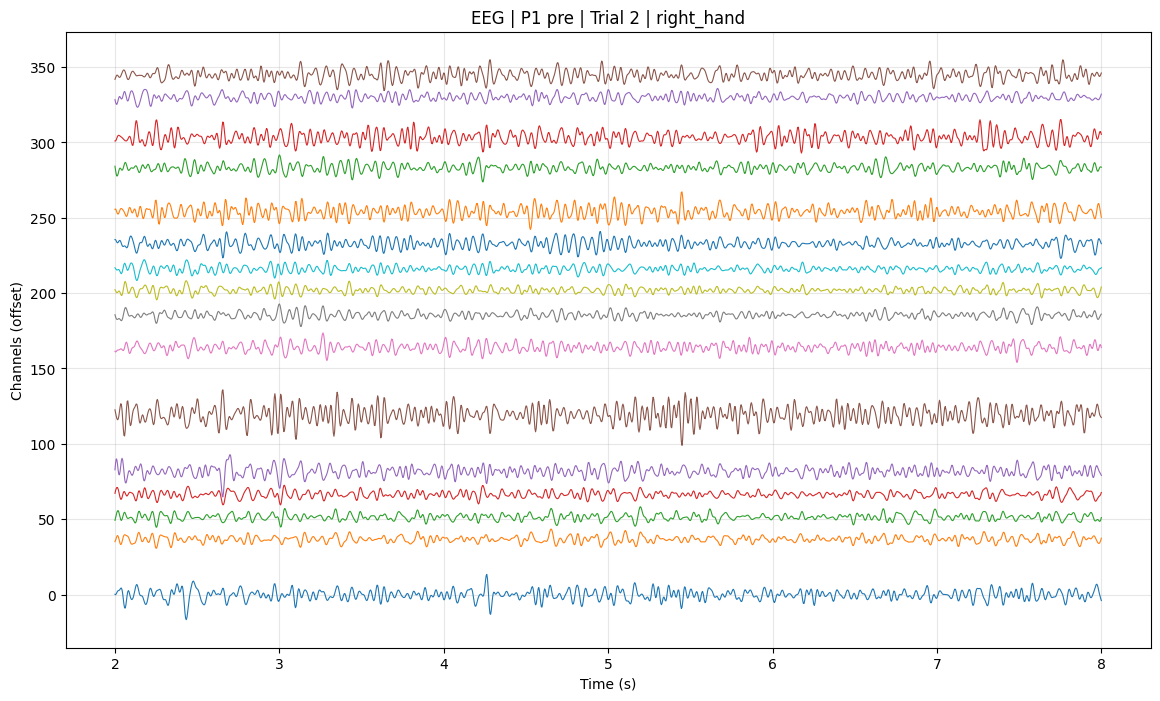

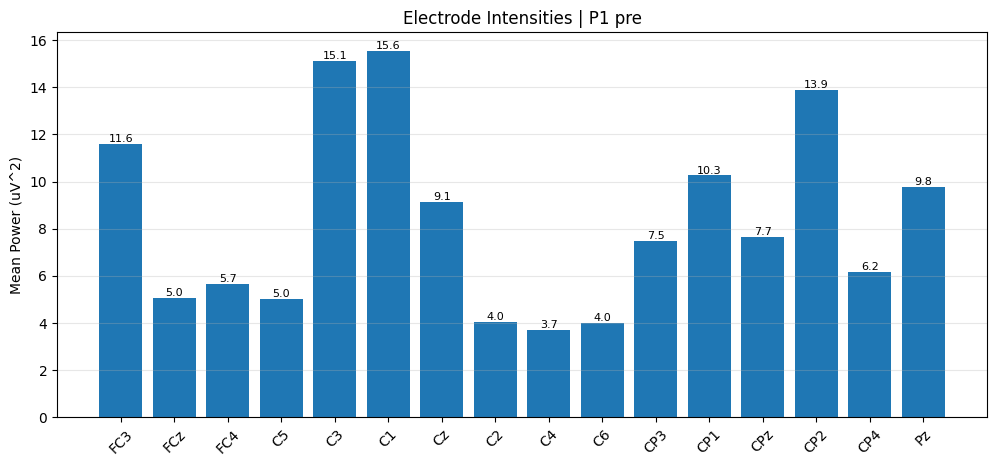

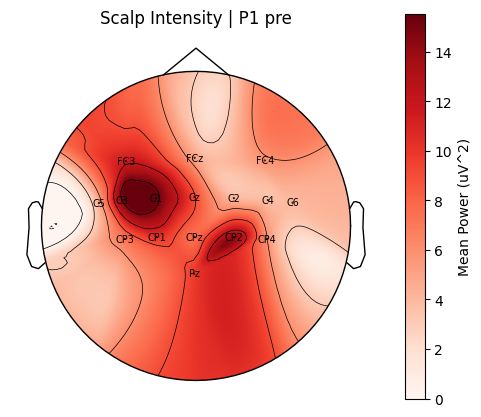

In [7]:
visualize_one_dataset(subject='P1', stage='pre')

In [8]:
# ============================================================
# RUN ONE TRAIN / TEST PAIR
# ============================================================

def run_one_pair(subject, stage):
    train_file = os.path.join(DATA_DIR, f"{subject}_{stage}_training.mat")
    test_file  = os.path.join(DATA_DIR, f"{subject}_{stage}_test.mat")

    print("\n" + "="*80)
    print(f"FB-FgMDM | Subject: {subject} | Stage: {stage.upper()}")
    print("="*80)

    _, X_train, y_train, fs = make_filterbank_epochs(train_file)
    _, X_test,  y_test,  _  = make_filterbank_epochs(test_file)

    print(f"Filter banks : {FILTER_BANKS}")
    print(f"X_train shape: {X_train.shape}  (trials, bands, channels, samples)")
    print(f"Train labels : {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"Test  labels : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

    model = build_fb_fgmdm_pipeline()
    cv    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_sc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")

    model.fit(X_train, y_train)
    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    train_acc, test_acc = accuracy_score(y_train, y_tr_pred), accuracy_score(y_test, y_te_pred)
    cv_acc, cv_std      = cv_sc.mean(), cv_sc.std()

    print(f"\nTraining : {train_acc*100:.2f}%  Test: {test_acc*100:.2f}%  CV: {cv_acc*100:.2f}% +/- {cv_std*100:.2f}%")
    print("\nClassification Report - TRAIN")
    print(classification_report(y_train, y_tr_pred, target_names=["left_hand","right_hand"]))
    print("\nClassification Report - TEST")
    print(classification_report(y_test,  y_te_pred, target_names=["left_hand","right_hand"]))

    cm = confusion_matrix(y_test, y_te_pred)
    ConfusionMatrixDisplay(cm, display_labels=["left_hand","right_hand"]).plot(cmap="Blues")
    plt.title(f"FB-FgMDM Confusion Matrix | {subject} {stage}"); plt.show()

    return dict(method="FB-FgMDM", subject=subject, stage=stage,
                train_acc=train_acc, test_acc=test_acc, cv_acc=cv_acc, cv_std=cv_std)



FB-FgMDM | Subject: P1 | Stage: PRE
Filter banks : [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
X_train shape: (80, 5, 16, 1537)  (trials, bands, channels, samples)
Train labels : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test  labels : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Training : 100.00%  Test: 92.50%  CV: 96.25% +/- 3.06%

Classification Report - TRAIN
              precision    recall  f1-score   support

   left_hand       1.00      1.00      1.00        40
  right_hand       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.95      0.90      0.92        40
  right_hand       0.90      0.95      0.93        40

    accuracy                           0.93        80
   macro avg       0.93    

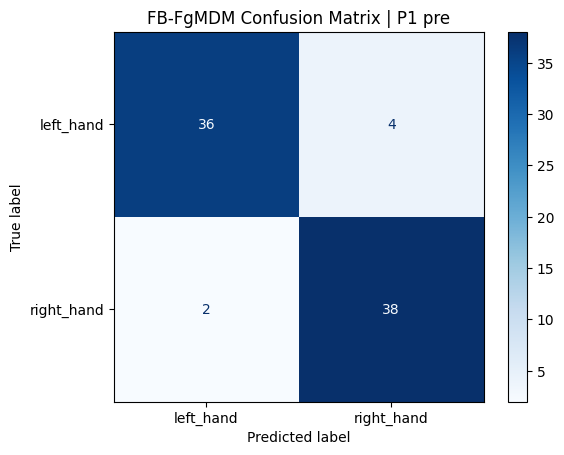


FB-FgMDM | Subject: P1 | Stage: POST
Filter banks : [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
X_train shape: (79, 5, 16, 1537)  (trials, bands, channels, samples)
Train labels : {np.int64(1): np.int64(39), np.int64(2): np.int64(40)}
Test  labels : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Training : 100.00%  Test: 97.50%  CV: 100.00% +/- 0.00%

Classification Report - TRAIN
              precision    recall  f1-score   support

   left_hand       1.00      1.00      1.00        39
  right_hand       1.00      1.00      1.00        40

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79


Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.97      0.97      0.97        40
  right_hand       0.97      0.97      0.97        40

    accuracy                           0.97        80
   macro avg       0.97  

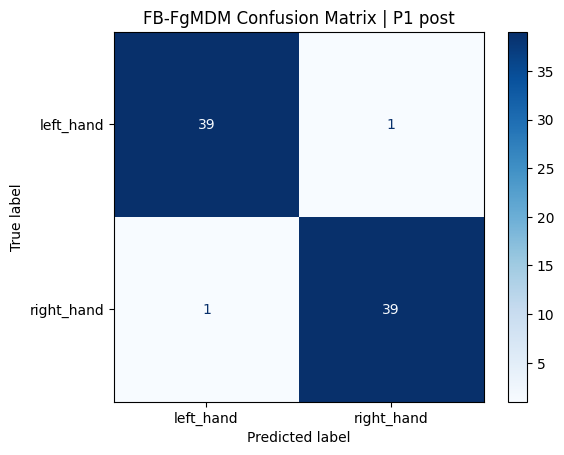


FB-FgMDM | Subject: P2 | Stage: PRE
Filter banks : [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
X_train shape: (80, 5, 16, 1537)  (trials, bands, channels, samples)
Train labels : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test  labels : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Training : 100.00%  Test: 81.25%  CV: 87.50% +/- 3.95%

Classification Report - TRAIN
              precision    recall  f1-score   support

   left_hand       1.00      1.00      1.00        40
  right_hand       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.79      0.85      0.82        40
  right_hand       0.84      0.78      0.81        40

    accuracy                           0.81        80
   macro avg       0.81    

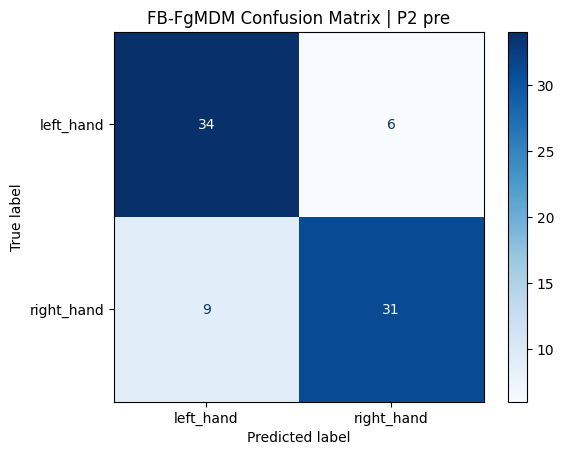


FB-FgMDM | Subject: P2 | Stage: POST
Filter banks : [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
X_train shape: (80, 5, 16, 1537)  (trials, bands, channels, samples)
Train labels : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test  labels : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Training : 100.00%  Test: 97.50%  CV: 96.25% +/- 5.00%

Classification Report - TRAIN
              precision    recall  f1-score   support

   left_hand       1.00      1.00      1.00        40
  right_hand       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.97      0.97      0.97        40
  right_hand       0.97      0.97      0.97        40

    accuracy                           0.97        80
   macro avg       0.97   

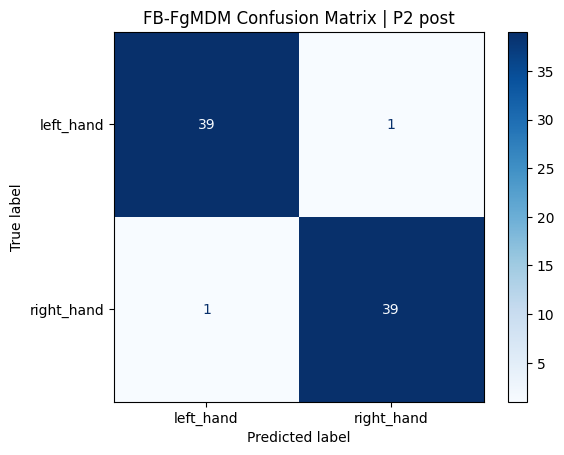


FB-FgMDM | Subject: P3 | Stage: PRE
Filter banks : [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
X_train shape: (79, 5, 16, 1537)  (trials, bands, channels, samples)
Train labels : {np.int64(1): np.int64(40), np.int64(2): np.int64(39)}
Test  labels : {np.int64(1): np.int64(40), np.int64(2): np.int64(39)}

Training : 100.00%  Test: 92.41%  CV: 97.42% +/- 3.17%

Classification Report - TRAIN
              precision    recall  f1-score   support

   left_hand       1.00      1.00      1.00        40
  right_hand       1.00      1.00      1.00        39

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79


Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.90      0.95      0.93        40
  right_hand       0.95      0.90      0.92        39

    accuracy                           0.92        79
   macro avg       0.93    

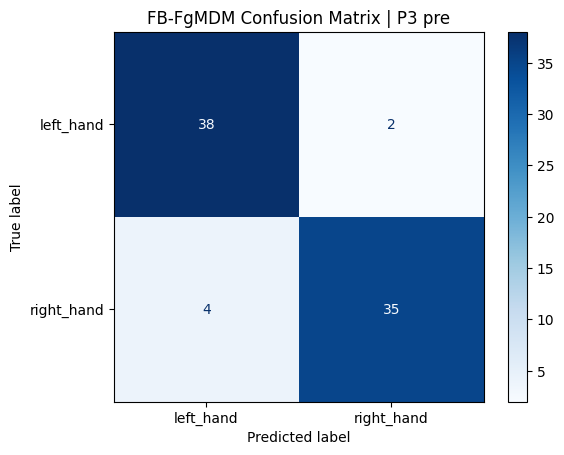


FB-FgMDM | Subject: P3 | Stage: POST
Filter banks : [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
X_train shape: (80, 5, 16, 1537)  (trials, bands, channels, samples)
Train labels : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test  labels : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Training : 100.00%  Test: 96.25%  CV: 92.50% +/- 7.29%

Classification Report - TRAIN
              precision    recall  f1-score   support

   left_hand       1.00      1.00      1.00        40
  right_hand       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.97      0.95      0.96        40
  right_hand       0.95      0.97      0.96        40

    accuracy                           0.96        80
   macro avg       0.96   

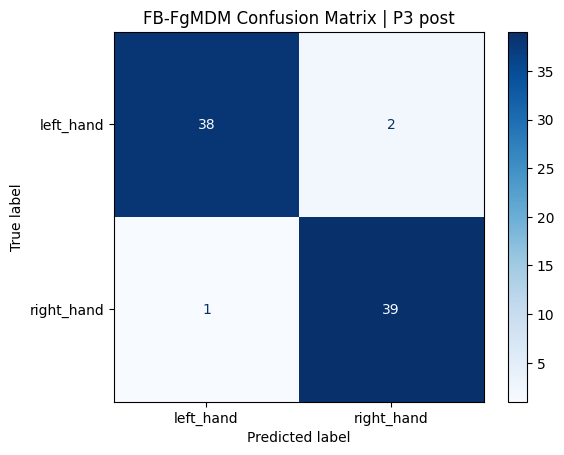

In [9]:
# ============================================================
# RUN ALL SUBJECTS AND STAGES
# ============================================================

results = []
for subject in SUBJECTS:
    for stage in STAGES:
        results.append(run_one_pair(subject, stage))




FB-FgMDM SUMMARY
P1  pre | Train: 100.00% | Test:  92.50% | CV:  96.25% +/- 3.06%
P1 post | Train: 100.00% | Test:  97.50% | CV: 100.00% +/- 0.00%
P2  pre | Train: 100.00% | Test:  81.25% | CV:  87.50% +/- 3.95%
P2 post | Train: 100.00% | Test:  97.50% | CV:  96.25% +/- 5.00%
P3  pre | Train: 100.00% | Test:  92.41% | CV:  97.42% +/- 3.17%
P3 post | Train: 100.00% | Test:  96.25% | CV:  92.50% +/- 7.29%


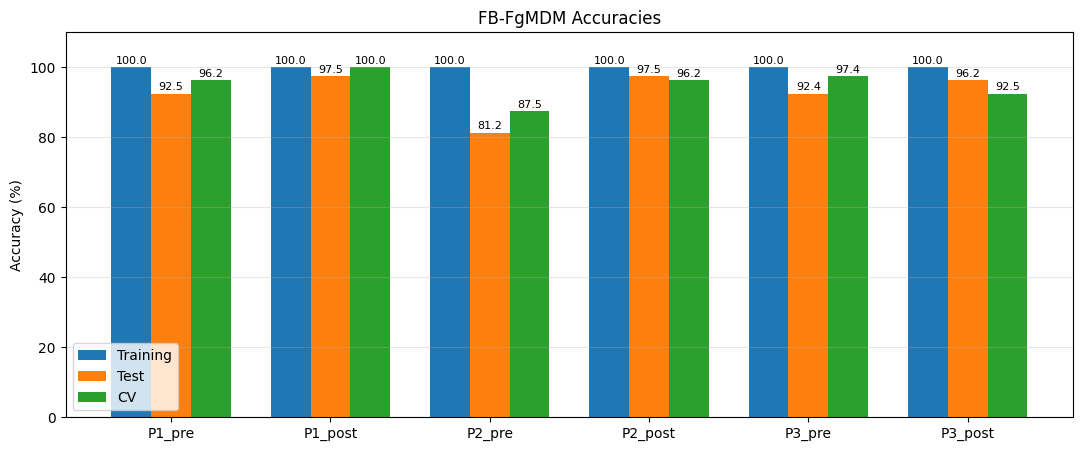

In [10]:
# ============================================================
# SUMMARY TABLE + BAR GRAPH
# ============================================================

method_name = results[0]["method"] if results else "FB"
print(f"\n\n{method_name} SUMMARY"); print("="*80)
for r in results:
    print(f"{r['subject']} {r['stage']:>4} | "
          f"Train: {r['train_acc']*100:6.2f}% | "
          f"Test: {r['test_acc']*100:6.2f}% | "
          f"CV: {r['cv_acc']*100:6.2f}% +/- {r['cv_std']*100:.2f}%")

labels     = [f"{r['subject']}_{r['stage']}" for r in results]
train_accs = [r["train_acc"]*100 for r in results]
test_accs  = [r["test_acc"] *100 for r in results]
cv_accs    = [r["cv_acc"]   *100 for r in results]

x, width = np.arange(len(labels)), 0.25
plt.figure(figsize=(13, 5))
plt.bar(x-width, train_accs, width, label="Training")
plt.bar(x,       test_accs,  width, label="Test")
plt.bar(x+width, cv_accs,    width, label="CV")
plt.xticks(x, labels); plt.ylabel("Accuracy (%)"); plt.ylim(0, 110)
plt.title(f"{method_name} Accuracies"); plt.legend(); plt.grid(axis="y", alpha=0.3)
for i, v in enumerate(train_accs): plt.text(i-width, v+1, f"{v:.1f}", ha="center", fontsize=8)
for i, v in enumerate(test_accs):  plt.text(i,       v+1, f"{v:.1f}", ha="center", fontsize=8)
for i, v in enumerate(cv_accs):    plt.text(i+width, v+1, f"{v:.1f}", ha="center", fontsize=8)
plt.show()
